In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import kagglehub
import os

# Download dataset
path = kagglehub.dataset_download("uciml/pima-indians-diabetes-database")
print("Dataset path:", path)

Using Colab cache for faster access to the 'pima-indians-diabetes-database' dataset.
Dataset path: /kaggle/input/pima-indians-diabetes-database


In [9]:

print("Files in dataset:", os.listdir(path))

Files in dataset: ['diabetes.csv']


In [10]:
# Load the CSV file
file_path = os.path.join(path, "diabetes.csv")
data = pd.read_csv(file_path)

In [11]:
# Display basic info
print("Loaded Data Shape:", data.shape)
display(data.head())

Loaded Data Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [12]:
# 2. Preprocess the dataset
## Handle missing values (on this dataset zeroes in certain columns are considered missing)
cols_with_missing = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in cols_with_missing:
    data[col] = data[col].replace(0, np.nan)
    data[col] = data[col].fillna(data[col].mean())

In [13]:
## Normalize/Standardize (z-score for all features except target)
X = data.drop('Outcome', axis=1)
y = data['Outcome'].values
X = (X - X.mean()) / X.std()

In [14]:
# 3. Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X.values, y, test_size=0.2, random_state=42)

In [15]:
# 4. Logistic Regression from scratch using batch gradient descent
class LogisticRegressionScratch:
    def __init__(self, lr=0.01, num_iter=1000):
        self.lr = lr
        self.num_iter = num_iter

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        self.b = 0
        m = len(y)
        for _ in range(self.num_iter):
            linear_model = np.dot(X, self.w) + self.b
            y_pred = self.sigmoid(linear_model)
            # Compute gradients
            dw = np.dot(X.T, (y_pred - y)) / m
            db = np.sum(y_pred - y) / m
            # Update weights
            self.w -= self.lr * dw
            self.b -= self.lr * db

    def predict_proba(self, X):
        return self.sigmoid(np.dot(X, self.w) + self.b)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

In [16]:
# Instantiate and train
model = LogisticRegressionScratch(lr=0.01, num_iter=1000)
model.fit(X_train, y_train)

In [17]:
# 5. Evaluate model
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

In [18]:
print(f"Accuracy   : {acc:.4f}")
print(f"Precision  : {prec:.4f}")
print(f"Recall     : {rec:.4f}")
print(f"F1 Score   : {f1:.4f}")

Accuracy   : 0.7403
Precision  : 0.6364
Recall     : 0.6364
F1 Score   : 0.6364


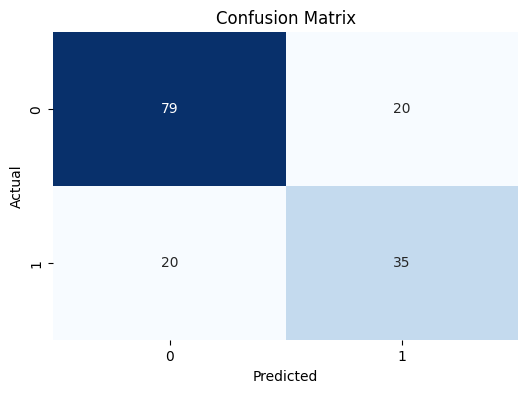

In [19]:
# 6. Plot the confusion matrix and explanation
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [20]:
## Explanation (2-3 sentences):
print("""
The confusion matrix shows that the model correctly identified 79 non-diabetic and 35 diabetic patients,
while misclassifying 20 from each group. Overall, it performs fairly well in distinguishing
between diabetic and non-diabetic patients but could improve by reducing false predictions.
""")


The confusion matrix shows that the model correctly identified 79 non-diabetic and 35 diabetic patients, 
while misclassifying 20 from each group. Overall, it performs fairly well in distinguishing 
between diabetic and non-diabetic patients but could improve by reducing false predictions.

